### Flagging Vendor Invoices for Manual Review
<b>Objective:</b> Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and pritorize human review where it adds the most value.
- manual invoice review is time consuming and does not scale with transaction volume.
- Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes or compilance risks.
- An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("D:\Placement Projects\invoice intelligence system\data\inventory.db")

In [3]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
    print('Table name', table)
    df = pd.read_sql_query(f"SELECT * FROM {table} limit 5", conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [7]:
purchased_agg_df = pd.read_sql_query("""
                select
                p.PONumber,
                count(distinct p.Brand) as total_brands,
                sum(p.Quantity) as total_item_quantity,
                sum(Dollars) as total_item_dollars,
                avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receving_delay
                from purchases p
                group by p.PONumber""",conn)

In [13]:
pd.read_sql_query("""
select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi
""",conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [15]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        count(distinct p.Brand) as total_brands,
        sum(p.Quantity) as total_item_quantity,
        sum(Dollars) as total_item_dollars,
        avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receving_delay
        from purchases p
        group by p.PONumber   
)

SELECT
    vi.PONumber,
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receving_delay
    
    from vendor_invoice vi
    LEFT JOIN purchase_agg pa ON vi.PONumber = pa.PONumber
""", conn)

In [16]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [17]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receving_delay     0
dtype: int64

In [18]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receving_delay     float64
dtype: object

In [20]:
def create_invoice_risk_label(row):
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1
    
    # Abnormally high receiving delay
    if row["avg_receving_delay"] > 10:
        return 1
    
    return 0

df['flag_invoice'] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

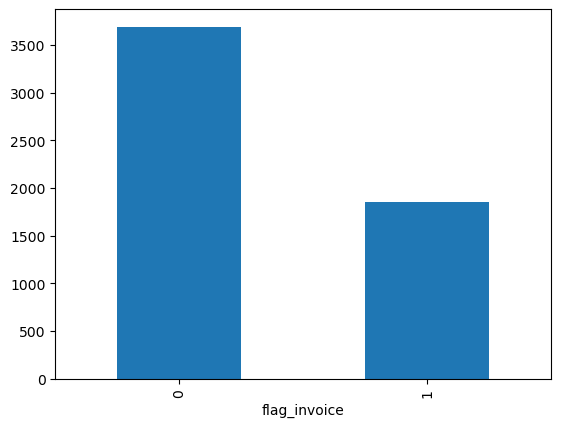

In [21]:
df['flag_invoice'].value_counts().plot(kind='bar')

In [22]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


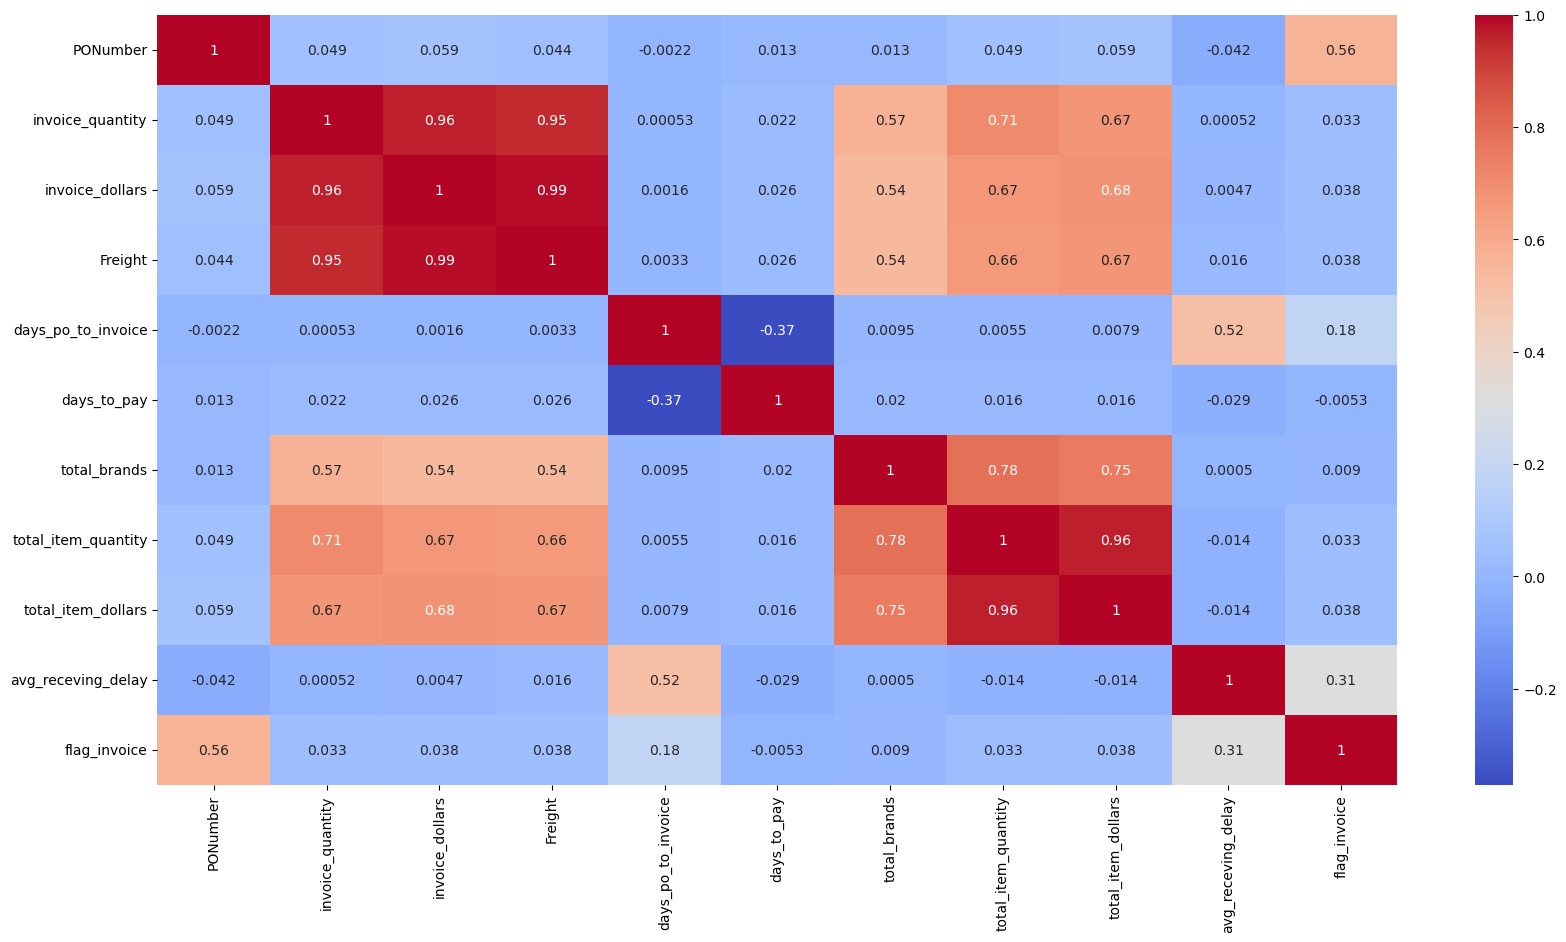

In [24]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [25]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [37]:
significant_features = []
non_significant_features = []
results = []

In [38]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receving_delay']

In [39]:
from scipy.stats import ttest_ind   
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    
    t_stat, p_value = ttest_ind(flagged[metric].dropna(), normal[metric].dropna(), equal_var=False)
    
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_features.append(metric)
        print(metric)
        print({
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })

days_to_pay
{'flagged_mean': np.float64(35.42), 'normal_mean': np.float64(35.49), 'p_value': np.float64(0.692)}
total_brands
{'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}


In [40]:
non_significant_features

['days_to_pay', 'total_brands']

In [41]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receving_delay']

In [42]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [43]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'total_brands', 'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [46]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_brands,total_item_quantity,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,41.0,6059.0,58073.0
std,14453.0,140234.0,714.0,3.0,77.0,14453.0,140234.0
min,1.0,4.0,0.0,9.0,1.0,1.0,4.0
25%,83.0,968.0,5.0,14.0,3.0,83.0,968.0
50%,423.0,4765.0,25.0,16.0,7.0,423.0,4765.0
75%,5100.0,44587.0,230.0,19.0,46.0,5100.0,44587.0
max,141660.0,1660436.0,8468.0,23.0,807.0,141660.0,1660436.0


In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier

In [60]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
from sklearn.metrics import classification_report, confusion_matrix
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"Evaluation for {model_name}:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

In [62]:
evaluate_model(model1, X_test_scaled, y_test, 'LogisticRegression')
evaluate_model(model2, X_test_scaled, y_test, 'DecisionTreeClassifier')
evaluate_model(model3, X_test_scaled, y_test, 'RandomForestClassifier')

Evaluation for LogisticRegression:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.59      0.06      0.10       384

    accuracy                           0.66      1109
   macro avg       0.63      0.52      0.45      1109
weighted avg       0.64      0.66      0.55      1109

Confusion Matrix:
[[710  15]
 [362  22]]


Evaluation for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0       0.77      0.43      0.55       725
           1       0.41      0.76      0.54       384

    accuracy                           0.54      1109
   macro avg       0.59      0.59      0.54      1109
weighted avg       0.65      0.54      0.55      1109

Confusion Matrix:
[[313 412]
 [ 93 291]]


Evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.80      0.50      0.62       725
           1       0.45      0.77     

In [63]:
model3.feature_importances_

array([0.1352116 , 0.15841764, 0.15006944, 0.07733046, 0.08312327,
       0.17421443, 0.22163315])

In [64]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.221633
5,total_item_quantity,0.174214
1,invoice_dollars,0.158418
2,Freight,0.150069
0,invoice_quantity,0.135212
4,total_brands,0.083123
3,days_po_to_invoice,0.077330


In [65]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

evaluate_model(model3, X_test_scaled, y_test, 'RandomForestClassifier')

Evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.84      0.45      0.59       725
           1       0.45      0.84      0.58       384

    accuracy                           0.59      1109
   macro avg       0.65      0.65      0.59      1109
weighted avg       0.71      0.59      0.59      1109

Confusion Matrix:
[[325 400]
 [ 60 324]]




In [68]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 4, 5, 6],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring=scorer, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'RandomForestClassifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Evaluation for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.86      0.46      0.60       725
           1       0.45      0.85      0.59       384

    accuracy                           0.59      1109
   macro avg       0.65      0.66      0.59      1109
weighted avg       0.72      0.59      0.59      1109

Confusion Matrix:
[[331 394]
 [ 56 328]]




In [69]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[331,  56],
       [394, 328]])

In [70]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[325,  60],
       [400, 324]])

In [72]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}